In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Analysis result:

In [8]:
result={'Unit':['Ignition','TSO'],
        'fsq694':[64.67,205.65]
}

print(result)

{'Unit': ['Ignition', 'TSO'], 'fsq694': [64.67, 205.65]}


Informe de Inicio, Parada e Inactividad 02-07-2026 12:00 am to 03-07-2026 11:59PM

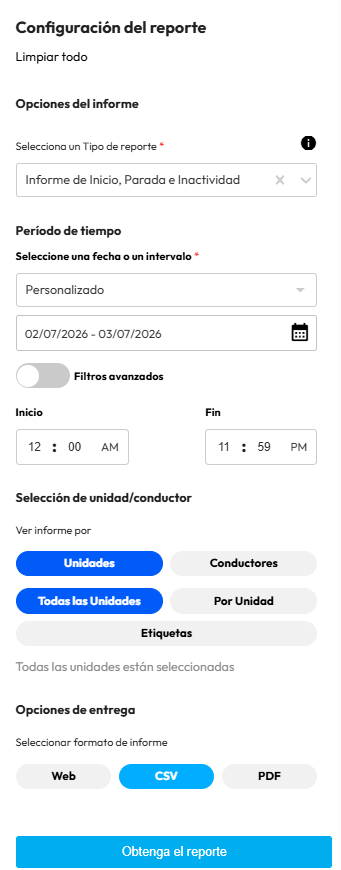

In [3]:
ipi=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\ipi0203_0726.csv',sep=',') 
ipi.info()

<class 'pandas.DataFrame'>
RangeIndex: 519 entries, 0 to 518
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unidad               519 non-null    str    
 1   Conductor            519 non-null    str    
 2   Evento               519 non-null    str    
 3   Dirección            519 non-null    str    
 4   Fecha                519 non-null    str    
 5   Tiempo (UTC-5)       519 non-null    str    
 6   Duración del Evento  519 non-null    str    
 7   Distancia (km)       52 non-null     float64
dtypes: float64(1), str(7)
memory usage: 32.6 KB


In [4]:
ipi_filtered=ipi[['Unidad','Distancia (km)']]
ipi_filtered.groupby('Unidad').sum()

,Distancia (km)
Unidad,
FSQ694,64.67
KYR910,79.82
NOX568,124.36


Reporte de actividades 02-07-2026 12:00 am to 03-07-2026 11:59PM

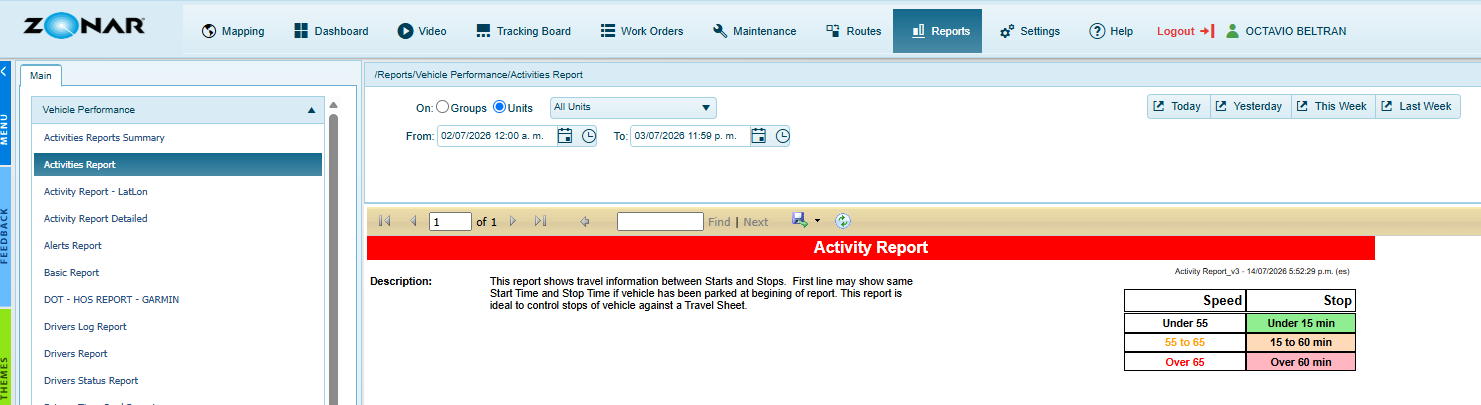

In [5]:
ar=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\Activity Report_v3 0203_0726.csv',sep=',')
ar['MilesDriven_float']=0.0
aux='s'
ar.info()
cad_str_to_float=[]

for i in range(0,ar.shape[0]):
    try:
        aux=ar.iloc[i,4].replace('.','')
        ar.iloc[i,4]=aux
        aux=ar.iloc[i,4].replace(',','.')
        cad_str_to_float.append(float(aux))
    except AttributeError as e:
        print("Error found on: ",ar.iloc[i,2],ar.iloc[i,1])
        cad_str_to_float.append(0.0)

ar['MilesDriven_float']=cad_str_to_float

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GroupName          0 non-null      float64
 1   UnitName           364 non-null    str    
 2   StartTime          364 non-null    str    
 3   MovingTimeSecs     364 non-null    str    
 4   MilesDriven        364 non-null    str    
 5   MaxSpeed           364 non-null    int64  
 6   StopTime           364 non-null    str    
 7   textbox43          364 non-null    str    
 8   StopLengthSecs     364 non-null    str    
 9   ContactName        364 non-null    str    
 10  textbox45          364 non-null    str    
 11  textbox54          364 non-null    int64  
 12  textbox28          364 non-null    str    
 13  textbox29          364 non-null    str    
 14  textbox30          364 non-null    int64  
 15  textbox32          364 non-null    str    
 16  MovingTimeSecs_1   364 non-null    st

In [6]:
ar_filtered=ar[['UnitName','MilesDriven_float']]
#ar_filtered.info()
ar_filtered.groupby('UnitName').sum()

,MilesDriven_float
UnitName,
Unit: FSQ694,105.65
Unit: KYR910,121.91
Unit: NOX568,232.88


In [7]:
ipi_filtered=ipi[['Unidad','Distancia (km)']]
ipi_filtered.groupby('Unidad').sum()

,Distancia (km)
Unidad,
FSQ694,64.67
KYR910,79.82
NOX568,124.36


Informe de kilometraje

In [10]:
mr=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\ort\mileageReport_0203_0726.csv',sep=',')
mr.info()

<class 'pandas.DataFrame'>
RangeIndex: 1734 entries, 0 to 1733
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unit                 1734 non-null   str    
 1   Time/Date (UTC-5)    1734 non-null   str    
 2   Address              1734 non-null   str    
 3   Distance (km)        1734 non-null   float64
 4   Total Distance (km)  1734 non-null   float64
 5   Odometer             1734 non-null   float64
 6   Driver               1734 non-null   str    
dtypes: float64(3), str(4)
memory usage: 95.0 KB


In [11]:
mr.groupby('Unit').sum()

,Time/Date (UTC-5),Address,Distance (km),Total Distance (km),Odometer,Driver
Unit,,,,,,
FSQ694,02/07/2026 6:12 AM02/07/2026 6:19 AM02/07/2026...,"145 - 46 Ac 145, Bogotá, Bogotá, 111151# 145-2...",105.91,24622.05,4447164.71,Conductor FSQ694Conductor FSQ694Conductor FSQ6...
KYR910,02/07/2026 5:16 AM02/07/2026 6:44 AM02/07/2026...,"49 Sur37 Cra 5l, Bogotá, Bogotá, 1118315l37 Cl...",122.29,32664.41,4487443.51,Conductor KYR910Conductor KYR910Conductor KYR9...
NOX568,02/07/2026 5:24 AM02/07/2026 5:25 AM02/07/2026...,"118-136 Cl. 47 Sur, Bogotá, Bogotá, 11044143b ...",235.17,93777.60,10993632.47,Conductor NOX568Conductor NOX568Conductor NOX5...
